# <center> Big Data For Finance Project: xxx Prediction Model

> - __Ahmed Abdelazeem__ (m20210433)
> - __Omar Jarir__ (m20201378)  
> - __Chung-Ting Huang__ (m20210437) 
> - __Pedro Moura Gomes__ (m20200322)

***

The goal of this project is to build following four Classification models to accurately classify "Response" variable:

- Logistic Regression.
- Random Forest.
- Gradient Boosted Tree.
- Artificial Neural Network.

- The used data set is from https://www.kaggle.com/code/lchen36/plotly-random-f-dtree-logistic-knn-auc-83/data

***

In [1]:
# Great this is working

import findspark
findspark.init('C:/spark') 
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [2]:
sc = spark.sparkContext

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif, f_classif, VarianceThreshold 
from sklearn.metrics import auc
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import sklearn.metrics as metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from sklearn import metrics

In [4]:
from pyspark.sql.functions import isnan, when, count, col
from pyspark.ml.classification import (LogisticRegression, RandomForestClassifier, GBTClassifier, 
                                       MultilayerPerceptronClassifier, DecisionTreeClassifier) 
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder, StandardScaler
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans 
from pyspark.sql.functions import udf
from pyspark.sql.types import FloatType

In [5]:
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import VectorAssembler, VectorIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

#import mlflow
#import mlflow.spark
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.ml.stat import Correlation

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
import time
t1 = time.perf_counter()

In [8]:
SEED = 2022

### Helper functions:

In [9]:
def MutualInfoScores(X, y):    
    mi = pd.Series(mutual_info_classif(X, y))
    mi /= mi.max()
    mi.index = X.columns
    mi.sort_values(ascending=False).plot.bar(figsize=(20, 6))
    plt.title("Feature univariate score")
    plt.ylabel('Mutual Information')
    plt.show();
    return mi

In [10]:
def FTestScores(X, y):
    f_scores = pd.Series(-np.log10(f_classif(X, y)[1]))
    f_scores /= f_scores.max()
    f_scores.index = X.columns
    f_scores = f_scores.sort_values(ascending=False)
    f_scores.plot.bar(figsize=(20,6))
    plt.title("Feature univariate score")
    plt.ylabel(r"Univariate score ($-Log(p_{value})$)")
    plt.show();
    return f_scores

In [11]:
def remove_correlated(X):
    corr = np.abs(X.corr())
    i = 1
    for (index, row) in corr.iterrows():
        for col in corr.columns[i:]:
            if row[col] > 0.9:
                print(f"{index} vs. {col} are highly correlated {row[col]}")
        i += 1
        # Select upper triangle of correlation matrix
    corr_matrix = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool))
    # Find features with correlation greater than 0.9
    correlated_cols = [c for c in corr_matrix.columns if any(corr_matrix[c] > 0.9)]
    # Drop correlated columns
    return correlated_cols

In [12]:
# Function to plot confusion matrix - Adapted from https://github.com/DTrimarchi10/confusion_matrix/blob/master/cf_matrix.py
def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):
    '''
    This function will make a pretty plot of an sklearn Confusion Matrix cm using a Seaborn heatmap visualization.
    Arguments
    ---------
    cf:            confusion matrix to be passed in
    group_names:   List of strings that represent the labels row by row to be shown in each square.
    categories:    List of strings containing the categories to be displayed on the x,y axis. Default is 'auto'
    count:         If True, show the raw number in the confusion matrix. Default is True.
    normalize:     If True, show the proportions for each category. Default is True.
    cbar:          If True, show the color bar. The cbar values are based off the values in the confusion matrix.
                   Default is True.
    xyticks:       If True, show x and y ticks. Default is True.
    xyplotlabels:  If True, show 'True Label' and 'Predicted Label' on the figure. Default is True.
    sum_stats:     If True, display summary statistics below the figure. Default is True.
    figsize:       Tuple representing the figure size. Default will be the matplotlib rcParams value.
    cmap:          Colormap of the values displayed from matplotlib.pyplot.cm. Default is 'Blues'
                   See http://matplotlib.org/examples/color/colormaps_reference.html
                   
    title:         Title for the heatmap. Default is None.
    '''


    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    ax = sns.heatmap(cf,annot=box_labels, fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)
    
    if title:
        plt.title(title)

In [13]:
def performanceMetricsDF(metricsObj, yTrain, yPredTrain, yTest, yPredTest):
    measures_list = ['ACCURACY','PRECISION', 'RECALL','F1 SCORE','AUC']
    train_results = [metricsObj.accuracy_score(yTrain, yPredTrain),
                metricsObj.precision_score(yTrain, yPredTrain, average='macro'),
                metricsObj.recall_score(yTrain, yPredTrain, average='macro'),
                metricsObj.f1_score(yTrain, yPredTrain, average='macro'),
                metricsObj.roc_auc_score(yTrain, yPredTrain, average='macro'),    
                ]
    test_results = [metricsObj.accuracy_score(yTest, yPredTest),
               metricsObj.precision_score(yTest, yPredTest, average='macro'),
               metricsObj.recall_score(yTest, yPredTest, average='macro'),
               metricsObj.f1_score(yTest, yPredTest, average='macro'),
               metricsObj.roc_auc_score(yTest, yPredTest, average='macro'), 
               ]
    resultsDF = pd.DataFrame({'Train': train_results, 'Test':test_results}, index=measures_list)
    return resultsDF

In [14]:
def Pipeline_model(stages, cv, train_data, test_data, eps=0.01):
    """
    
    """
    p = Pipeline(stages=stages + [cv]) 
    pipeline_model = p.fit(train_data)
    predDF = pipeline_model.transform(test_data)
    
    # I should avoid using collect because of the dataset size.


    
#     y_test = predDF.select(["Response"]).collect()
#     y_pred_test = predDF.select(["prediction"]).collect()
#     firstelement = udf(lambda v: float(v[1]), FloatType())
#     y_pred_test_proba = predDF.select(firstelement('probability')).collect()
    
#     print(classification_report(y_test, y_pred_test))
    
    
    return pipeline_model, predDF
# , y_test, y_pred_test, y_pred_test_proba

In [15]:
def Metrics(predDF, eps= 0.01):
    
    # Create and print a confusion matrix:
    print("The confusion matrix of our model is as follow:\n")
    cm = predDF.groupBy("label", 'prediction').count().toPandas() 

    cm = pd.pivot_table(cm, values='count', index=['label'],
                    columns=['prediction'], aggfunc=np.sum, fill_value=0)
    display(cm)
    
    # Calculate the elements of the confusion matrix
    TN = predDF.filter('prediction = 0 AND label = prediction').count()
    TP = predDF.filter('prediction = 1 AND label = prediction').count()
    FN = predDF.filter('prediction = 0 AND label != prediction').count()
    FP = predDF.filter('prediction = 1 AND label != prediction').count()

    # Accuracy measures the proportion of correct predictions
    accuracy = (TN+TP)/(TN+TP+FN+FP+eps)
    precision = TP/(TP+FP+eps)
    recall = TP/(TP+FN+eps)
    F1 = 2*precision*recall/(precision+recall+eps)
    print(f"The accuracy value is equal to {accuracy:.2f}")
    print(f"The precision value is equal to {precision:.2f}")
    print(f"The recall value is equal to {recall:.2f}")
    print(f"The F1-score value is equal to {F1:.2f}")
    
    binary_evaluator = BinaryClassificationEvaluator()
    auc = binary_evaluator.evaluate(predDF, {binary_evaluator.metricName:"areaUnderROC"})
    print(f"The auc value is equal to {auc:.2f}")

In [16]:
def auc_plot(y_test, y_pred_test_proba):
    fpr, tpr, _ = roc_curve(y_test, y_pred_test_proba)
    auc_keras = auc(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.plot(fpr, tpr, label='AUC (area = {:.3f})'.format(auc_keras), color="g")
    plt.grid(axis='both', linestyle='--', color="#add8e6")
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title('ROC curve')
    plt.legend(loc='best')
    plt.show();

***

### Loading the data:

In [17]:
# # # # # Load and parse the data file, converting it to a DataFrame.

# # # # # data = spark.read.csv("train.csv", header="true", sep=",", inferSchema="true")
# data = pd.read_csv("train.csv").sample(frac=0.1, random_state =SEED)

In [18]:
# data.shape

In [19]:
# X, y = data.drop(columns=["Response"]).reset_index(drop=True) , data["Response"].reset_index(drop=True)

In [20]:
# X.columns

In [21]:
# # X.columns
# ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage"]

In [22]:
# from collections import Counter
# from imblearn.over_sampling import SMOTE, ADASYN, SMOTENC
# X_resampled, y_resampled = SMOTENC(categorical_features=[1, 3, 4, 5, 6, 7], random_state=SEED).fit_resample(X, y)
# print(sorted(Counter(y_resampled).items()))

In [23]:
# pd.concat([X_resampled, y_resampled], axis=1).to_csv("Inssurance_data.csv")

In [24]:
#data = spark.createDataFrame(data=data)

In [25]:
data = spark.read.csv("Inssurance_data.csv", header="true", sep=",", inferSchema="true")

In [26]:
data = data.withColumnRenamed("Response", "label")

In [27]:
data.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Driving_License: integer (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: integer (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: integer (nullable = true)
 |-- label: integer (nullable = true)



In [28]:
data = data.drop("_c0")

In [29]:
data.toPandas().tail()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,label
66699,49163,Female,34,1,28.0,0,1-2 Year,Yes,34273.663086,133.079570,134,1
66700,58211,Male,25,1,4.0,0,< 1 Year,Yes,26256.918020,148.621704,215,1
66701,281615,Male,46,1,41.0,0,1-2 Year,Yes,2630.000000,157.000000,45,1
66702,103335,Female,27,1,28.0,0,1-2 Year,Yes,2630.000000,150.474717,143,1
66703,82640,Female,46,1,31.0,0,1-2 Year,Yes,2630.000000,160.587309,269,1


In [30]:
data.show(5, truncate=False, vertical=True)

-RECORD 0------------------------
 id                   | 122810   
 Gender               | Male     
 Age                  | 52       
 Driving_License      | 1        
 Region_Code          | 30.0     
 Previously_Insured   | 0        
 Vehicle_Age          | 1-2 Year 
 Vehicle_Damage       | Yes      
 Annual_Premium       | 2630.0   
 Policy_Sales_Channel | 156.0    
 Vintage              | 180      
 label                | 0        
-RECORD 1------------------------
 id                   | 226069   
 Gender               | Male     
 Age                  | 40       
 Driving_License      | 1        
 Region_Code          | 28.0     
 Previously_Insured   | 0        
 Vehicle_Age          | 1-2 Year 
 Vehicle_Damage       | Yes      
 Annual_Premium       | 29651.0  
 Policy_Sales_Channel | 124.0    
 Vintage              | 47       
 label                | 0        
-RECORD 2------------------------
 id                   | 152073   
 Gender               | Male     
 Age          

In [31]:
data.count()

66704

In [32]:
# Checking if the data frame contains duplicates
data.distinct().count()

66700

In [33]:
data.select([count(when(isnan(c), c)).alias(c) for c in data.columns]).toPandas()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,label
0,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
# Dropping the "id" columns.

data = data.drop(col("id"))

***

## Data exploration:

In [35]:
data.describe().toPandas().T

,0,1,2,3,4
summary,count,mean,stddev,min,max
Gender,66704,None,None,Female,Male
Age,66704,40.45262652914368,13.523235413322341,20,85
Driving_License,66704,0.9990855121132166,0.030226896896593136,0,1
Region_Code,66704,26.74703166226913,11.78920074561834,0.0,52.0
Previously_Insured,66704,0.2623230990645239,0.4399006613156981,0,1
Vehicle_Age,66704,None,None,1-2 Year,> 2 Years
Vehicle_Damage,66704,None,None,No,Yes
Annual_Premium,66704,30923.949067160855,17512.887471018374,2630.0,495106.0
Policy_Sales_Channel,66704,103.85516381688613,51.83335841303143,1.0,163.0


In [36]:
data.createOrReplaceTempView("dataTable")

In [37]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Driving_License: integer (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: integer (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: integer (nullable = true)
 |-- label: integer (nullable = true)



In [38]:
# As we can see from the query bellow the number of zero response is way higher than 1.

spark.sql("""SELECT count(*) as _count, label
          From dataTable
          Group by label
          ORDER BY _count""").show()

+------+-----+
|_count|label|
+------+-----+
| 33352|    1|
| 33352|    0|
+------+-----+



In [39]:
# As we can see from the query bellow the number of males in the dataset is higher than the number of females.

spark.sql("""SELECT gender, count(gender) as gender_count
          From dataTable
          Group by gender
          ORDER BY gender_count""").show()

+------+------------+
|gender|gender_count|
+------+------------+
|Female|       26229|
|  Male|       40475|
+------+------------+



In [40]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Driving_License: integer (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: integer (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: integer (nullable = true)
 |-- label: integer (nullable = true)



In [41]:
# We can notice few age difference between the responders.

spark.sql("""SELECT mean(Age) as mean_age, label
          From dataTable
          Group by label
          ORDER BY mean_age""").show()

+------------------+-----+
|          mean_age|label|
+------------------+-----+
|38.051061405612856|    0|
|  42.8541916526745|    1|
+------------------+-----+



In [42]:
# We can see that almost half of the vehicles had danmage.

spark.sql("""SELECT count(Vehicle_Damage) as count_vehicle_damage, Vehicle_damage
          From dataTable
          Group by Vehicle_damage
          ORDER BY count_vehicle_damage""").show()

+--------------------+--------------+
|count_vehicle_damage|Vehicle_damage|
+--------------------+--------------+
|               18870|            No|
|               47834|           Yes|
+--------------------+--------------+



In [43]:
data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Driving_License: integer (nullable = true)
 |-- Region_Code: double (nullable = true)
 |-- Previously_Insured: integer (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: integer (nullable = true)
 |-- label: integer (nullable = true)



In [44]:
# We have too many regions code, we decide to drop this variable.

spark.sql("""SELECT DISTINCT count(Region_Code) as count_region_code, Region_Code
          From dataTable
          Group by Region_Code
          ORDER BY count_region_code""").show()

+-----------------+-----------+
|count_region_code|Region_Code|
+-----------------+-----------+
|               39|       51.0|
|               43|       52.0|
|               45|       42.0|
|               99|       44.0|
|              136|        1.0|
|              153|       22.0|
|              177|       40.0|
|              188|        5.0|
|              199|       34.0|
|              213|       49.0|
|              246|       16.0|
|              249|       19.0|
|              263|        4.0|
|              264|       17.0|
|              267|       25.0|
|              278|        0.0|
|              278|       23.0|
|              313|       20.0|
|              318|       24.0|
|              318|       26.0|
+-----------------+-----------+
only showing top 20 rows



In [45]:
data = data.drop(col("Region_Code"))

In [46]:
# We have too many regions code, we decide to drop this variable.

spark.sql("""SELECT DISTINCT count(Vehicle_Damage) as count_vehicle_damage, Vehicle_Damage
          From dataTable
          Group by Vehicle_Damage
          ORDER BY count_vehicle_damage""").show()

+--------------------+--------------+
|count_vehicle_damage|Vehicle_Damage|
+--------------------+--------------+
|               18870|            No|
|               47834|           Yes|
+--------------------+--------------+



In [47]:
spark.sql("""SELECT DISTINCT count(Driving_License) as count_Driving_License, Driving_License
          From dataTable
          Group by Driving_License
          ORDER BY count_Driving_License""").show()

+---------------------+---------------+
|count_Driving_License|Driving_License|
+---------------------+---------------+
|                   61|              0|
|                66643|              1|
+---------------------+---------------+



In [48]:
### Here i should add some groupBy things, there are many interesting things to check.

In [49]:
# This is a nice thing to check.

data.describe("Age").show()

+-------+------------------+
|summary|               Age|
+-------+------------------+
|  count|             66704|
|   mean| 40.45262652914368|
| stddev|13.523235413322341|
|    min|                20|
|    max|                85|
+-------+------------------+



In [50]:
# Getting the average of all the numerical features.
display(data.select(["label", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('label').avg().toPandas())

,label,avg(label),avg(Age),avg(Annual_Premium),avg(Policy_Sales_Channel),avg(Vintage)
0,1,1.0,42.854192,31361.883173,92.669101,152.720227
1,0,0.0,38.051061,30486.014962,115.041227,154.893979


In [51]:
display(data.select(["label", "Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]).groupBy('label').avg().toPandas())

,label,avg(label),avg(Age),avg(Annual_Premium),avg(Policy_Sales_Channel),avg(Vintage)
0,1,1.0,42.854192,31361.883173,92.669101,152.720227
1,0,0.0,38.051061,30486.014962,115.041227,154.893979


In [52]:
# As we can see no features have correlation above the pre set threshold.

correlated_cols = remove_correlated(data.toPandas())
correlated_cols

[]

In [53]:
# Split the dataset intro train and test sets.

train_data, test_data = data.randomSplit([0.7, 0.3], seed=SEED)

In [54]:
x_train = train_data.toPandas()
x_test = test_data.toPandas()

y_train = x_train["label"]
x_train = x_train.drop(columns=["label"])

y_test = x_test["label"]
x_test = x_test.drop(columns=["label"])

In [55]:
# We use an isolation forest in order to drop the outliers.
# I can't use it because i have categorical features.

In [56]:
# classifier = IsolationForest(n_estimators=100, random_state=SEED)

# #identify outliers:
# y_train_pred = classifier.fit_predict(x_train)
# y_val_pred = classifier.predict(x_val)
# y_test_pred = classifier.predict(x_test)

# #Remove outliers where 1 represent inliers and -1 represent outliers:
# x_train = x_train[np.where(y_train_pred == 1, True, False)]
# x_val = x_val[np.where(y_val_pred == 1, True, False)]
# x_test = x_test[np.where(y_test_pred == 1, True, False)]

# y_train = y_train[np.where(y_train_pred == 1, True, False)]
# y_val = y_val[np.where(y_val_pred == 1, True, False)]
# y_test = y_test[np.where(y_test_pred == 1, True, False)]

In [57]:
# I still have the issue of the categorical features. 
# MutualInfoScores(x_train, y_train)

In [58]:
# I still have the issue of the categorical features.
# f_scores = FTestScores(x_train, y_train)

In [59]:
# selector = SelectKBest(f_classif, k=len(f_scores.loc[f_scores > 0.4]))

# # selecting the features:
# selector.fit(x_train, y_train)

# kept_columns = list(x_train.columns[selector.get_support()]) 

In [60]:
# kept_columns

In [61]:
# x_train = x_train[kept_columns]
# x_val = x_val[kept_columns]
# x_test = x_test[kept_columns]

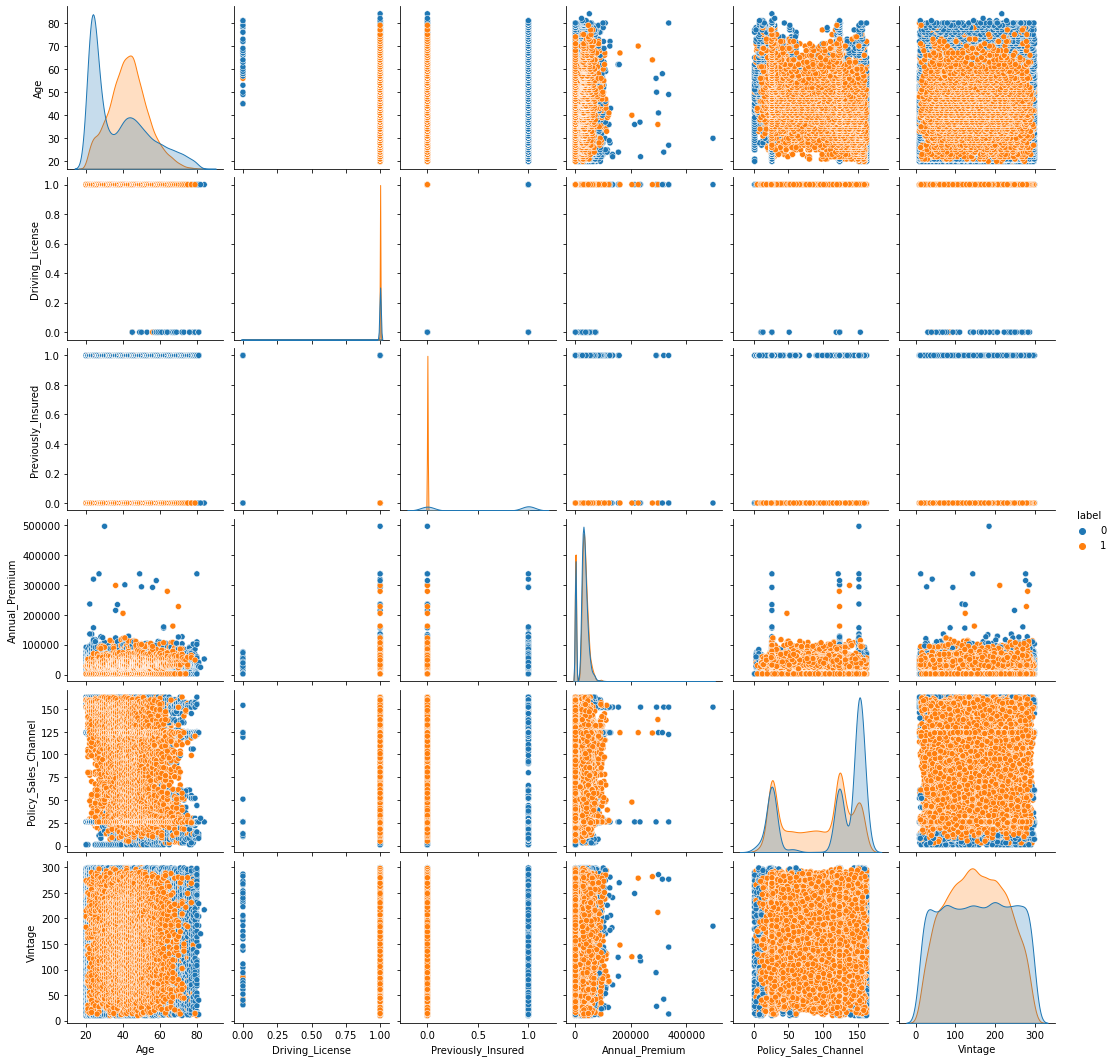

In [62]:
# This one takes a lot of time as well i should definitely sample the data.

sns.pairplot(pd.concat([x_train, y_train], axis=1), hue="label")

In [63]:
def plot_histogram(df, feat_name, bins=20, figsize=(20,10)):  
    hists = df.select(feat_name).rdd.flatMap(lambda row: row).histogram(bins)

    data = {
       'bins': hists[0][:-1],
       'freq': hists[1]
      }
    plt.figure(figsize=figsize)
    plt.bar(data['bins'], data['freq'], width=2000)
    plt.title('Histogram of \'{}\''.format(feat_name))
    plt.show();

In [64]:
train_data = spark.createDataFrame(data=pd.concat([x_train, y_train], axis=1))
test_data = spark.createDataFrame(data=pd.concat([x_test, y_test], axis=1))

In [65]:
train_data.cache()
test_data.cache()

DataFrame[Gender: string, Age: bigint, Driving_License: bigint, Previously_Insured: bigint, Vehicle_Age: string, Vehicle_Damage: string, Annual_Premium: double, Policy_Sales_Channel: double, Vintage: bigint, label: bigint]

***

# Modelling:

## Data preparation:

In [66]:
features_columns = ["Gender", "Age", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage",]

In [67]:
train_data.printSchema()

root
 |-- Gender: string (nullable = true)
 |-- Age: long (nullable = true)
 |-- Driving_License: long (nullable = true)
 |-- Previously_Insured: long (nullable = true)
 |-- Vehicle_Age: string (nullable = true)
 |-- Vehicle_Damage: string (nullable = true)
 |-- Annual_Premium: double (nullable = true)
 |-- Policy_Sales_Channel: double (nullable = true)
 |-- Vintage: long (nullable = true)
 |-- label: long (nullable = true)



In [68]:
featuresCols = train_data.columns 
featuresCols.remove("label")

In [69]:
categoricalCols = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage"]
numericCols = ["Age", "Annual_Premium", "Policy_Sales_Channel", "Vintage"]

indexOutputCols = [f + "_Index" for f in categoricalCols]
oheOutputCols = [f + "_OHE" for f in categoricalCols]

stringIndexer = StringIndexer(inputCols=categoricalCols, outputCols=indexOutputCols, handleInvalid="skip")
oheEncoder = OneHotEncoder(inputCols=indexOutputCols, outputCols=oheOutputCols)
assembler = VectorAssembler(inputCols=numericCols, outputCol= "numfeatures")
scaler = StandardScaler(inputCol="numfeatures", outputCol="scaledFeatures")

vectorAssembler = VectorAssembler(inputCols=oheOutputCols+["scaledFeatures"], outputCol="features")

In [70]:
## I should pay serious attention to the split as, if we split now we will not get the same results.

In [71]:
stages = [stringIndexer, oheEncoder, assembler, scaler, vectorAssembler]

In [72]:
# Thr order of features.

features_names = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Age",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage"]

***

## Logistic regression

In [73]:
lr = LogisticRegression(featuresCol="features", labelCol="label")

In [74]:
evaluator=BinaryClassificationEvaluator(labelCol="label", rawPredictionCol='prediction', metricName='areaUnderROC')

- elasticNetParam=1, means Lasso.
- elasticNetParam=0, means Ridge.

- There are two parameters for this model, λ (regParam) and α (elasticNetParam), where α determines the type of regularization and λ gives the strength of regularization.

In [75]:
paramGrid=ParamGridBuilder() \
                .addGrid(lr.regParam, (0.01, 0.1))\
                .addGrid(lr.maxIter, (5, 10))\
                .addGrid(lr.tol, (1e-4, 1e-5))\
                .addGrid(lr.elasticNetParam, (0.0, 1.0))\
                .build()

In [76]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  16


In [77]:



# It is good to use a lasso regression as it will, gives some coefficients equal to 0. 

In [78]:
cv_lr = CrossValidator(estimator=lr,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [79]:
pipeline_model, predDF = Pipeline_model(stages, cv_lr, train_data, test_data)

In [80]:
Metrics(predDF)

The confusion matrix of our model is as follow:



prediction,0.0,1.0
label,,
0,7188,2772
1,811,9244


The accuracy value is equal to 0.82
The precision value is equal to 0.77
The recall value is equal to 0.92
The F1-score value is equal to 0.83
The auc value is equal to 0.88


In [81]:
cv_model = pipeline_model.stages[-1]
lr_summary = cv_model.bestModel.summary

In [82]:
# cv_model.bestModel.extractParamMap()

In [83]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getRegParam())
print(cv_model.bestModel.getMaxIter())
print(cv_model.bestModel.getTol())
print(cv_model.bestModel.getElasticNetParam())

0.01
10
0.0001
0.0


In [84]:
cv_model.bestModel.getParam("regParam")

Param(parent='LogisticRegression_65c64d2afc68', name='regParam', doc='regularization parameter (>= 0).')

In [85]:
features_names = ["Gender", "Driving_License", "Previously_Insured", "Vehicle_Age", "Vehicle_Damage", "Age",
  "Annual_Premium", "Policy_Sales_Channel", "Vintage"]


features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.coefficients)),
                             columns=["feature", "Coefficient"]).sort_values(by=["Coefficient"], ascending=False)

display(features_imp)

,feature,Coefficient
5,Age,2.591732
2,Previously_Insured,2.311929
1,Driving_License,2.091055
3,Vehicle_Age,0.836300
0,Gender,0.331074
7,Policy_Sales_Channel,0.047756
8,Vintage,-0.141467
6,Annual_Premium,-0.394844
4,Vehicle_Damage,-1.175444


In [86]:
# Number of zero coefficients:

zero_coeff = sum([beta==0 for beta in cv_model.bestModel.coefficients])
print("The number of coefficients equal to 0 is:", zero_coeff)

The number of coefficients equal to 0 is: 0


In [87]:
# list(zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics))

***

## Random forest model:

In [88]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [89]:
evaluator=BinaryClassificationEvaluator(labelCol="label", rawPredictionCol='prediction', metricName='areaUnderROC')

In [90]:
paramGrid=ParamGridBuilder() \
                .addGrid(rf.maxDepth, [5, 10, 20]) \
                .addGrid(rf.numTrees, [20, 40, 60 ]) \
                .build()

#                 .addGrid(rf.maxBins, [20, 32, 50]) \
#                 .addGrid(rf.minInfoGain, [0., 0.01, 0.1]) \
#                 .addGrid(rf.impurity, ["gini", "entropy"]) \
#                 .addGrid(rf.minInstancesPerNode, [1, 5, 10]) \    

In [91]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  9


In [92]:
# The other way arround is better I guess:

cv_rf = CrossValidator(estimator=rf,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [93]:
pipeline_model, predDF = Pipeline_model(stages, cv_rf, train_data, test_data)

In [94]:
Metrics(predDF)

The confusion matrix of our model is as follow:



prediction,0.0,1.0
label,,
0,7997,1963
1,779,9276


The accuracy value is equal to 0.86
The precision value is equal to 0.83
The recall value is equal to 0.92
The F1-score value is equal to 0.87
The auc value is equal to 0.95


In [95]:
cv_model = pipeline_model.stages[-1]
rf_summary = cv_model.bestModel.summary
rf_summary

In [96]:
cv_model.bestModel.extractParamMap()

{Param(parent='RandomForestClassifier_e057b36660c7', name='bootstrap', doc='Whether bootstrap samples are used when building trees.'): True,
 Param(parent='RandomForestClassifier_e057b36660c7', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False,
 Param(parent='RandomForestClassifier_e057b36660c7', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10,
 Param(parent='RandomForestClassifier_e057b36660c7', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree node. Supp

In [97]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxDepth())
print(cv_model.bestModel.getNumTrees)

20
40


In [98]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
5,Age,0.297083
8,Vintage,0.161011
2,Previously_Insured,0.144179
4,Vehicle_Damage,0.118203
6,Annual_Premium,0.118159
7,Policy_Sales_Channel,0.055176
3,Vehicle_Age,0.033550
0,Gender,0.009562
1,Driving_License,0.000473


In [99]:
# list(zip(cv_model.getEstimatorParamMaps(), cv_model.avgMetrics))

***

## Neural Network:

In [100]:
nn = MultilayerPerceptronClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [101]:
paramGrid=ParamGridBuilder().addGrid(nn.maxIter, [50, 100]).addGrid(nn.layers, [[10, 5, 2]]).build()

In [102]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  2


In [103]:
cv_nn = CrossValidator(estimator=nn,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [104]:
pipeline_model, predDF = Pipeline_model(stages, cv_nn, train_data, test_data)

In [105]:
Metrics(predDF)

The confusion matrix of our model is as follow:



prediction,0.0,1.0
label,,
0,7432,2528
1,664,9391


The accuracy value is equal to 0.84
The precision value is equal to 0.79
The recall value is equal to 0.93
The F1-score value is equal to 0.85
The auc value is equal to 0.90


In [106]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

MultilayerPerceptronClassificationModel: uid=MultilayerPerceptronClassifier_f58cd57c1c3a, numLayers=3, numClasses=2, numFeatures=10

In [107]:
cv_model.bestModel.extractParamMap()

{Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='blockSize', doc='block size for stacking input data in matrices. Data is stacked within partitions. If block size is more than remaining data in a partition then it is adjusted to the size of this data.'): 128,
 Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='featuresCol', doc='features column name.'): 'features',
 Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='labelCol', doc='label column name.'): 'label',
 Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='maxIter', doc='max number of iterations (>= 0).'): 100,
 Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='predictionCol', doc='prediction column name.'): 'prediction',
 Param(parent='MultilayerPerceptronClassifier_f58cd57c1c3a', name='probabilityCol', doc='Column name for predicted class conditional probabilities. Note: Not all models output well-calibrated probability estimates! These probabilitie

In [108]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxIter())
print(cv_model.bestModel.getLayers())

100
[10, 5, 2]


***

## Gradient Boosting:

In [109]:
gb = GBTClassifier(featuresCol="features", labelCol="label", seed=SEED)

In [110]:
paramGrid=ParamGridBuilder().addGrid(gb.maxDepth, [5, 8]).addGrid(gb.minInstancesPerNode, [5]).build()

## this takes too much time, i need to tweak it to get better results.
#.addGrid(gb.maxBins, [20, 32, 50]) \
                #.addGrid(gb.maxIter, [10, 20, 30]) \

In [111]:
# How many models?
print('Number of models to be tested: ', len(paramGrid))

Number of models to be tested:  2


In [112]:
# The other way arround is better I guess:

cv_gb = CrossValidator(estimator=gb,
                        evaluator=evaluator,
                        estimatorParamMaps=paramGrid,
                        numFolds=3,
                        parallelism=4,
                        seed=SEED)

In [113]:
pipeline_model, predDF = Pipeline_model(stages, cv_gb, train_data, test_data)

In [114]:
Metrics(predDF)

The confusion matrix of our model is as follow:



prediction,0.0,1.0
label,,
0,7871,2089
1,736,9319


The accuracy value is equal to 0.86
The precision value is equal to 0.82
The recall value is equal to 0.93
The F1-score value is equal to 0.86
The auc value is equal to 0.94


In [115]:
cv_model = pipeline_model.stages[-1]
cv_model.bestModel

GBTClassificationModel: uid = GBTClassifier_013220c5a1a9, numTrees=20, numClasses=2, numFeatures=10

In [116]:
cv_model.bestModel.extractParamMap()

{Param(parent='GBTClassifier_013220c5a1a9', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False,
 Param(parent='GBTClassifier_013220c5a1a9', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10,
 Param(parent='GBTClassifier_013220c5a1a9', name='featureSubsetStrategy', doc="The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for r

In [117]:
# Better way the show the hyperparameters:

print(cv_model.bestModel.getMaxDepth())
print(cv_model.bestModel.getMinInstancesPerNode())

8
5


In [118]:
features_imp = pd.DataFrame(list(zip(features_names, cv_model.bestModel.featureImportances)),
                             columns=["feature", "importance"])

features_imp.sort_values(by="importance", ascending=False)

,feature,importance
5,Age,0.491018
8,Vintage,0.205813
6,Annual_Premium,0.087519
3,Vehicle_Age,0.044350
7,Policy_Sales_Channel,0.043552
2,Previously_Insured,0.035216
4,Vehicle_Damage,0.019608
0,Gender,0.013475
1,Driving_License,0.000666


***

In [119]:
t2 = time.perf_counter()
print('Time taken to run in minutes:',(t2-t1)/60.0)

Time taken to run in minutes: 14.699128696666666
